# Why is there a one day periodicity in drifter-altimetry time gap diagnosis ? 
## Necklace

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

________________________
# 1/ Fixed the pearls color/order :
## 11/Get typical temporal variability from drifter velocity

HF
LF
inertial
diurnal
semidiurnal


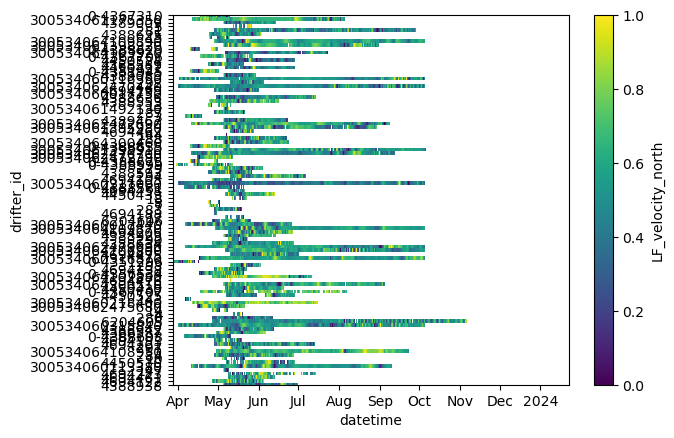

In [2]:
ds = xr.open_dataset('/Users/mdemol/DATA_DRIFTERS/drifters_harmonized_old/L2/all_med_variational_10min_v0.nc').set_coords('drifter_type')
ds['drifter_id'] = ds.drifter_id.astype(str)
def filter_traj(ds, T=20, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88],'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
 
        taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
        dss[c+'_velocity_east'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_east),
            dims=["drifter_id", "datetime"],
            )
        dss[c+'_velocity_north'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_north),
            dims=["drifter_id","datetime"],
            )
        dss[c+'_acceleration_east'] = (
            (dss[c+'_velocity_east'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_east.attrs)
        )
        dss[c+'_acceleration_north'] = (
            (dss[c+'_velocity_north'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_north.attrs)
        )
        print(c)
    
    return dss

ds_ = ds.isel(drifter_id = slice(0,100))
dsi = filter_traj(ds_).where(ds_.gap_mask==1)


# Min = 0 + normalized 
min_, max_ = dsi.LF_velocity_north.min('datetime'), dsi.LF_velocity_north.max('datetime')

dso = (dsi.LF_velocity_north - min_)/(max_-min_)
dso['time'] = (dso.datetime - dso.datetime.min())/pd.Timedelta('1d')
dso.plot()

________
## 12/ What if linear dependence ?

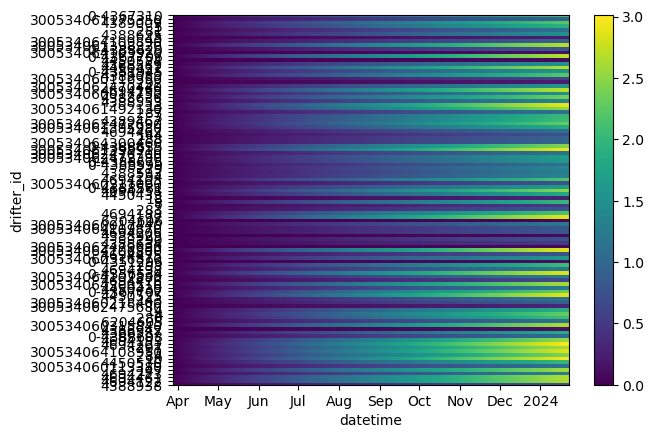

In [49]:
dsl = xr.ones_like(dso)
dsl = dsl*(dsl.time)/100
dsl = dsl * xr.DataArray(data = np.random.rand(len(dsl.drifter_id)), coords = {'drifter_id' :dsl.drifter_id})
dsl.plot()

________
## 13/ What if sinusoide ?

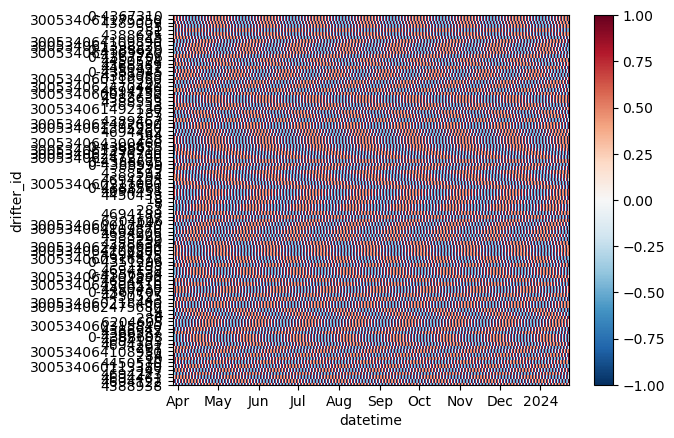

In [53]:
dsn = xr.ones_like(dso)
phi = xr.DataArray(data = np.random.rand(len(dsn.drifter_id))*2*np.pi, coords = {'drifter_id' :dsl.drifter_id})
T = xr.DataArray(data = np.ones(len(dsn.drifter_id))*2.234, coords = {'drifter_id' :dsl.drifter_id})

dsn = dsn*np.sin(2*np.pi*dsn.time/T + phi)
dsn.plot()

# 2/ Build necklaces for all the different swot images : select the drifter points/pearls at +-10 days
## 21/ One drifter

In [7]:
i = 3
dt_drifter = 10/60/24 #10min in days

traj = dso.isel(drifter_id=i).dropna('datetime')
t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
traj['datetime'] = t                            

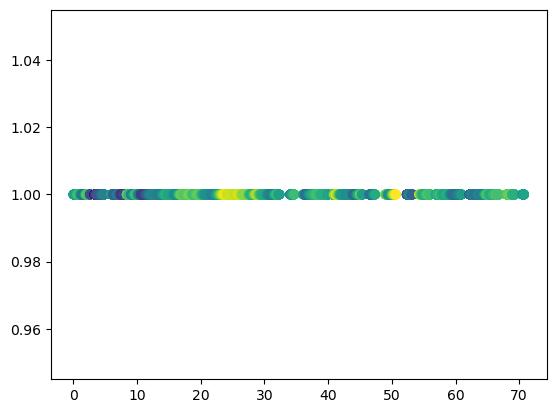

In [8]:
plt.scatter(t, np.ones_like(t), c = traj.values)

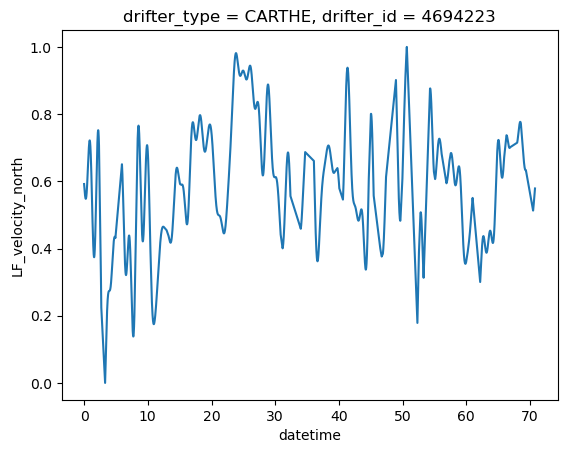

In [46]:
traj.plot()

In [55]:
def select_traj(traj, tswot):
    tneg =  np.sort(np.arange(0, -10-dt_drifter, -dt_drifter))
    tpos = np.sort(np.arange(dt_drifter, 10, dt_drifter))
    ts = np.concatenate([tneg, tpos])
    tneg =  np.sort(np.arange(0, 10-dt_drifter, -dt_drifter))
    dd = traj.interp(datetime=ts+tswot)
    dd['datetime'] = ts
    return dd
dtswot= 3
Tswot = np.arange(0, 40, dtswot)

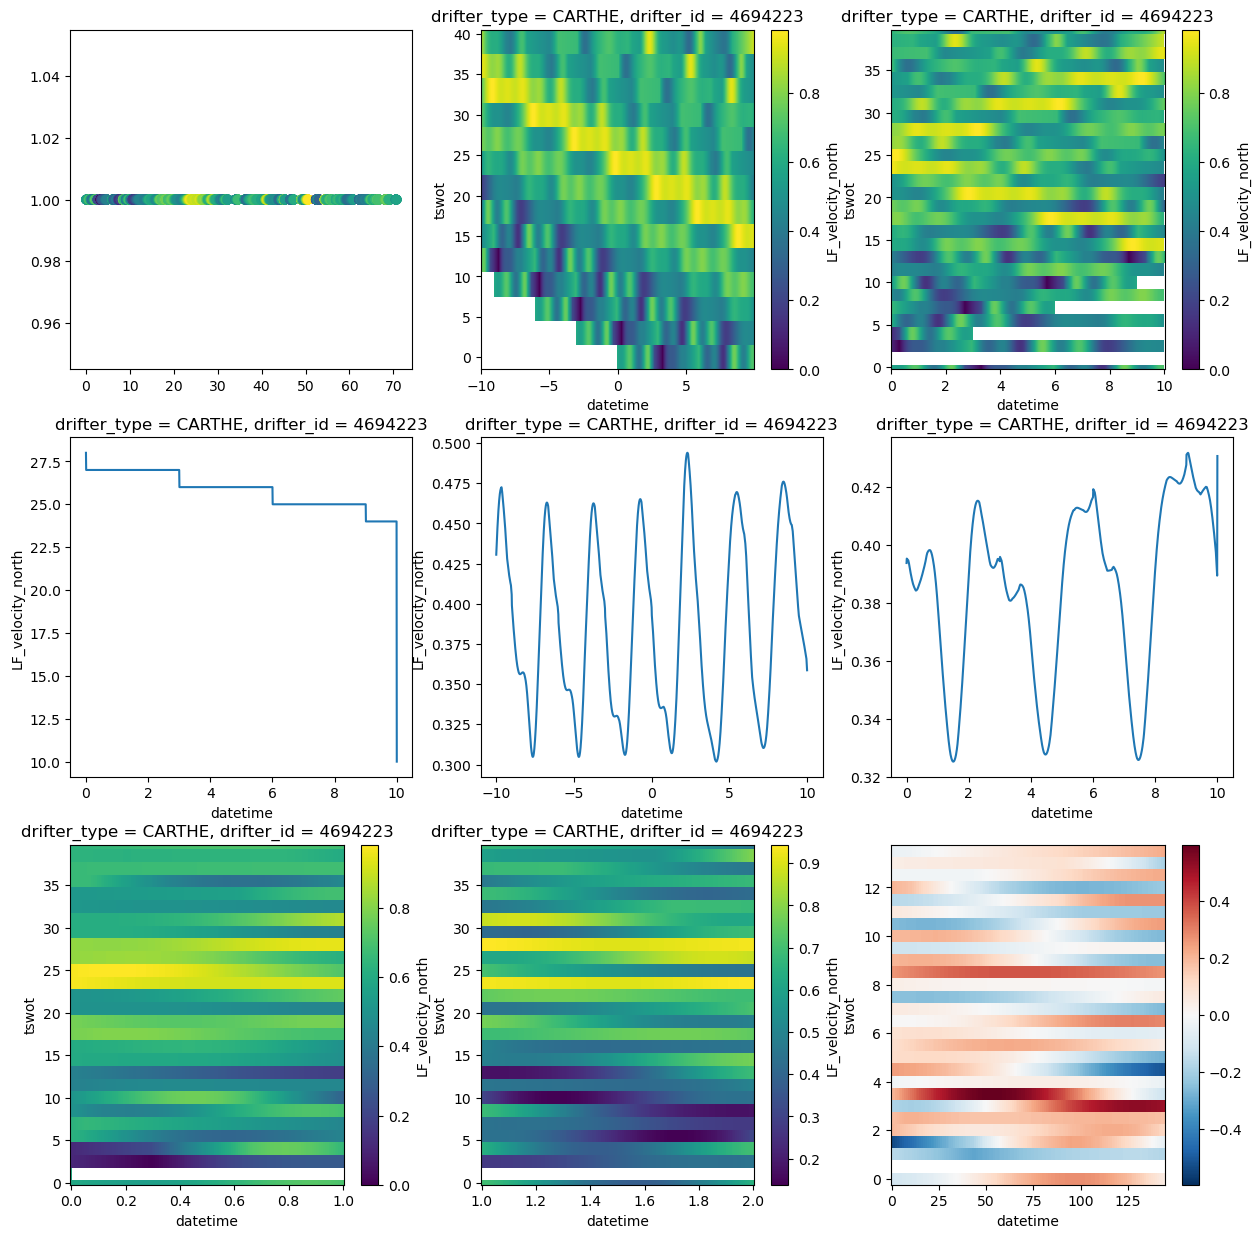

In [58]:
def print_for_one_traj(ds, i):
    dt_drifter = 10/60/24 #10min in days
    fig, axs = plt.subplots(3,3, figsize=(15, 15))
    axs = axs.flatten()
    #select traj
    traj = ds.isel(drifter_id=i).dropna('datetime')
    t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
    traj['datetime'] = t  
    axs[0].scatter(t, np.ones_like(t), c = traj.values)

    def build_necklace(traj, tswot):
        tneg =  np.sort(np.arange(0, -10-dt_drifter, -dt_drifter))
        tpos = np.sort(np.arange(dt_drifter, 10, dt_drifter))
        ts = np.concatenate([tneg, tpos])
        tneg =  np.sort(np.arange(0, 10-dt_drifter, -dt_drifter))
        dd = traj.interp(datetime=ts+tswot)
        dd['datetime'] = ts
        return dd
    
    dtswot= 3
    Tswot = np.arange(0, 40, dtswot)
    
    D = []
    for ts in Tswot :
        D.append(build_necklace(traj, ts))
    dsp = xr.concat(D, pd.Index(Tswot, name = 'tswot'))
    dsp.plot(ax=axs[1])
    
    pos = dsp.where(dsp.datetime >= 0, drop=True)
    neg = dsp.where(dsp.datetime <= 0, drop=True)
    neg['datetime'] = - neg['datetime']
    neg['tswot'] = neg['tswot']+ 0.5
    concat = xr.concat([pos, neg], dim = 'tswot')
    concat = concat.sortby('tswot')
    concat.plot(ax=axs[2])
    concat.count(dim='tswot').plot(ax=axs[3])
    (concat**2).mean('tswot').plot(ax=axs[5])
    (dsp**2).mean('tswot').plot(ax=axs[4])
    #concat.sel(tswot=slice(10, None)).mean('tswot').plot(ax=axs[5])
    
    concat.sel(datetime=slice(0,1)).plot(ax=axs[6])
    concat.sel(datetime=slice(1, 2)).plot(ax=axs[7])
    diff = concat.sel(datetime=slice(0, 1)).values - concat.sel(datetime=slice(1, 2)).values
    
    diff = xr.DataArray(diff, coords={'tswot':np.arange(0, diff.shape[0]/2, 0.5),'datetime':np.arange(diff.shape[1]) })
    diff.plot(ax=axs[8])
    #concat.sel(datetime=slice(2,3)).plot(ax=axs[8])

    return traj, dsp, concat

traj, dsp, concat = print_for_one_traj(dso, 3)

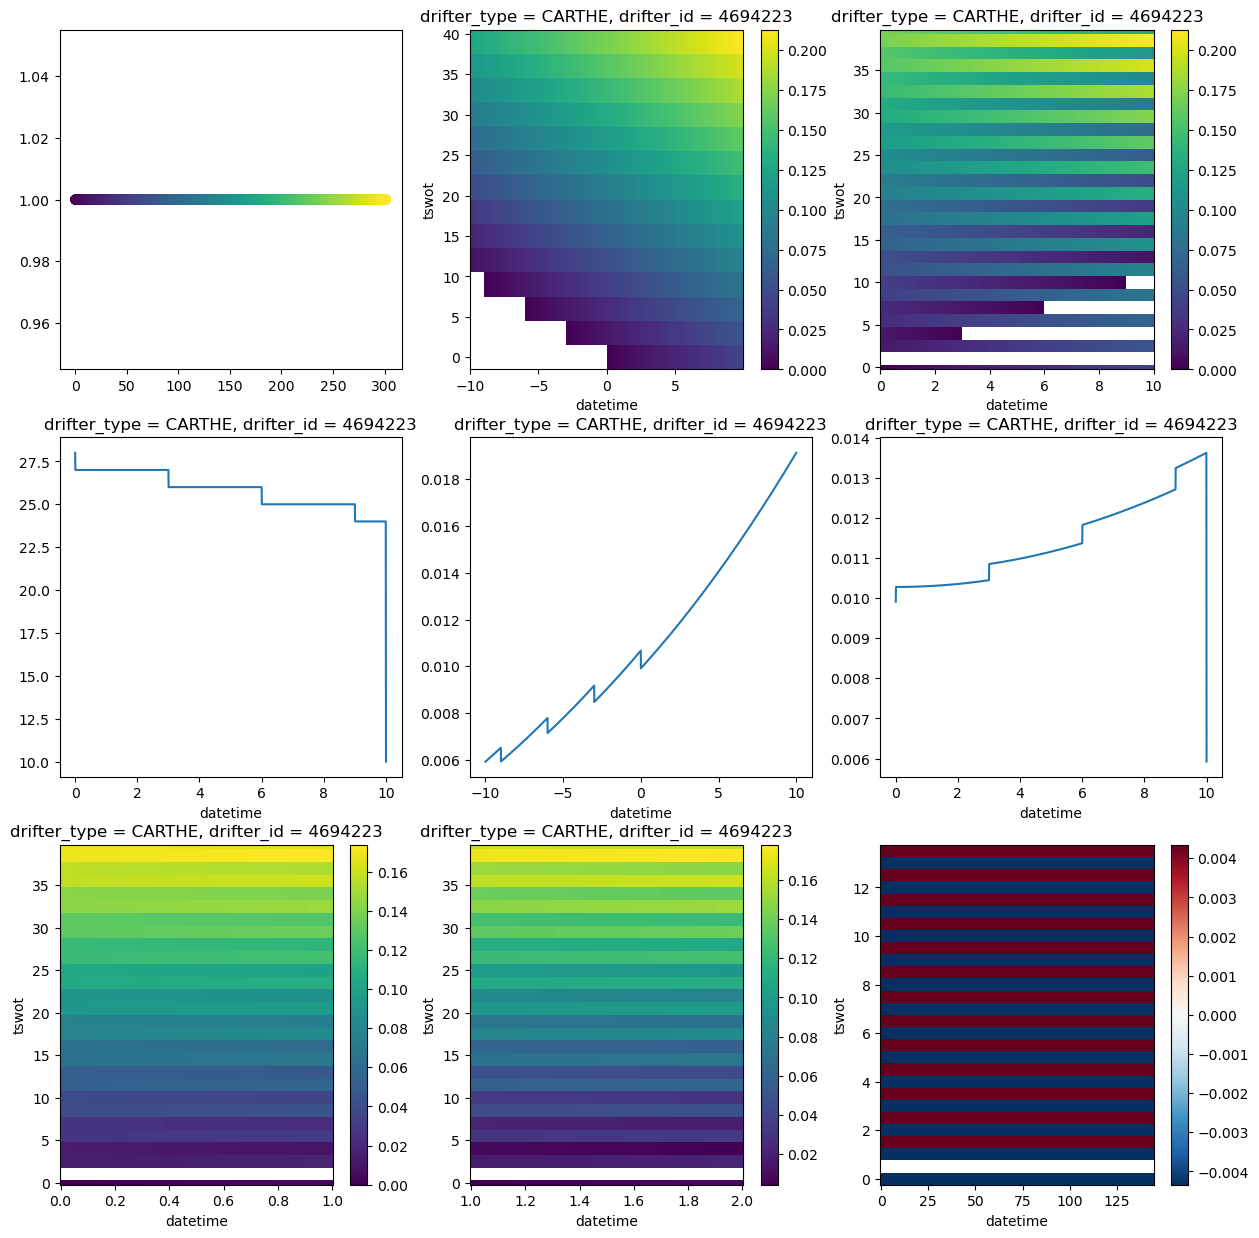

In [59]:
traj, dsp, concat = print_for_one_traj(dsl, 3)

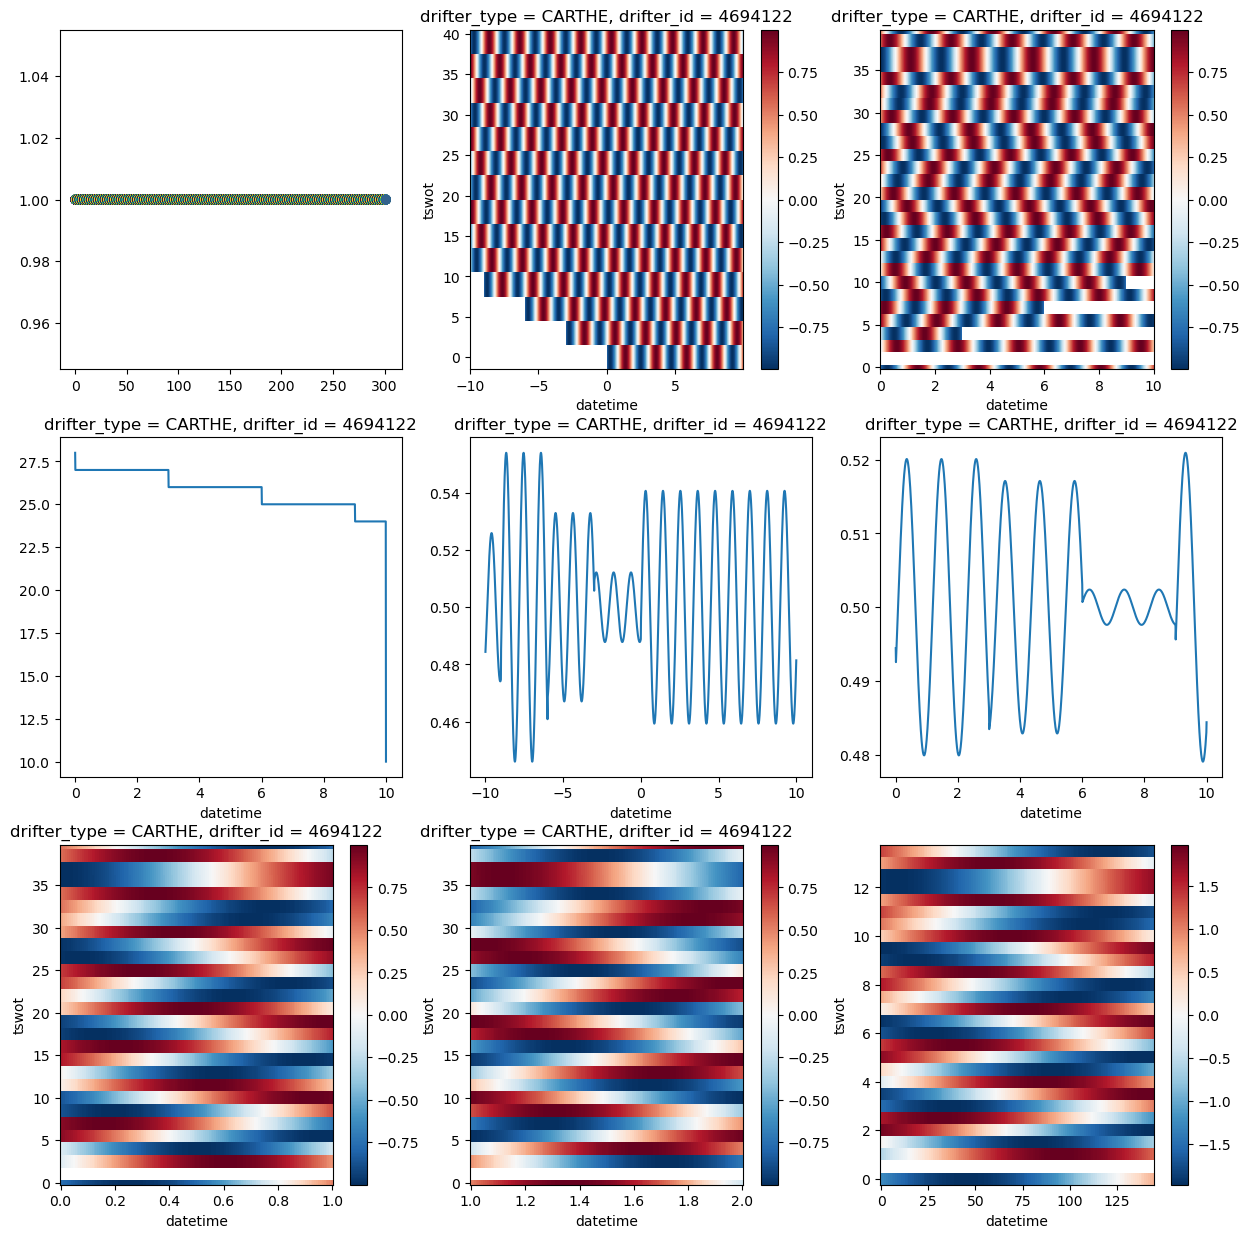

In [60]:
traj, dsp, concat = print_for_one_traj(dsn, 1)

In [61]:
dsp

<xarray.DataArray (tswot: 14, datetime: 2880)> Size: 323kB
array([[        nan,         nan,         nan, ...,  0.59943571,
         0.61495379,  0.63023729],
       [        nan,         nan,         nan, ...,  0.33763296,
         0.31918522,  0.30061572],
       [        nan,         nan,         nan, ..., -0.97152823,
        -0.96671576, -0.96153452],
       ...,
       [-0.42129311, -0.40350034, -0.38555365, ..., -0.71147348,
        -0.69761366, -0.68348772],
       [ 0.98896026,  0.98587763,  0.98241892, ...,  0.97844722,
         0.98229353,  0.98576513],
       [-0.66860262, -0.68299814, -0.69713312, ..., -0.36683622,
        -0.38493492, -0.40288677]])
Coordinates:
    drifter_type  <U7 28B 'CARTHE'
    drifter_id    <U15 60B '4694122'
    time          (tswot, datetime) float64 323kB nan nan nan ... 48.99 48.99
  * datetime      (datetime) float64 23kB -10.0 -9.993 -9.986 ... 9.986 9.993
  * tswot         (tswot) int64 112B 0 3 6 9 12 15 18 21 24 27 30 33 36 39

## 22/ For all 

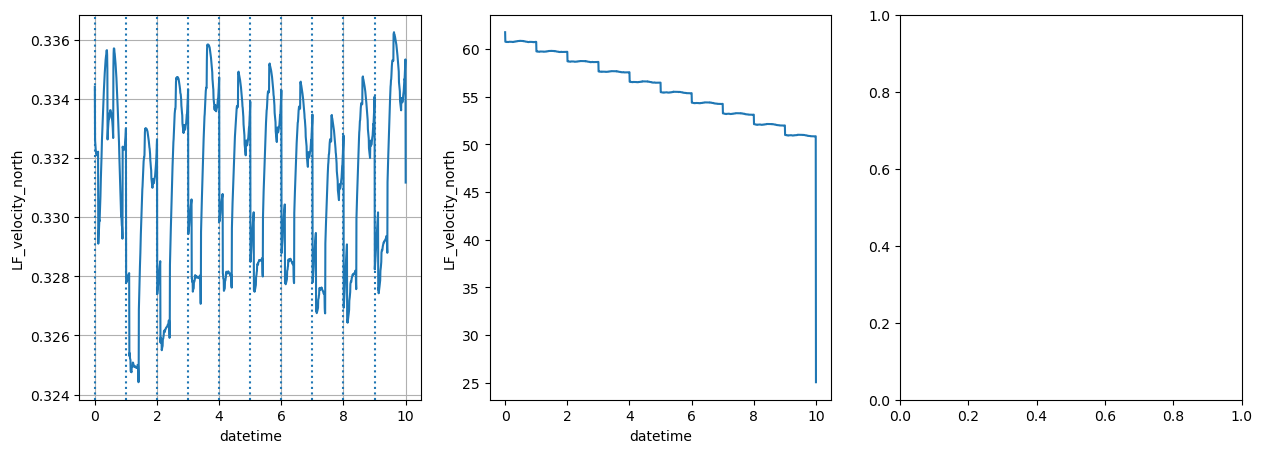

In [25]:
def print_for_all(ds):
    dtswot= 1
    Tswot = np.arange(0, 40, dtswot)
    DD = []
    for d in ds.drifter_id.values :
        traj = ds.sel(drifter_id=d).dropna('datetime')
        try : 
            t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
        except : continue
        traj['datetime'] = t
        D = []
        for ts in Tswot :
            D.append(select_traj(traj, ts))
        DD.append(xr.concat(D, pd.Index(Tswot, name = 'tswot')))
    dsf = xr.concat(DD, dim = 'drifter_id')
    pos = dsf.where(dsf.datetime >= 0, drop=True)
    neg = dsf.where(dsf.datetime <= 0, drop=True)
    neg['datetime'] = - neg['datetime']
    neg['tswot'] = neg['tswot']+ 0.5
    fconcat = xr.concat([pos, neg], dim = 'tswot')

    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    ax=axs[0]
    (fconcat**2).mean('tswot').mean('drifter_id').plot(ax=ax)
    for i in range(0, 10) :
        ax.axvline(i, ls=':')
    ax.grid()

    fconcat.count(dim='tswot').mean('drifter_id').plot(ax=axs[1])
    return dsf, fconcat

dsf, fconcat = print_for_all(dso)   

____
# 4/ Can we extract physical info from this ?
## 41/ Adding temporal decorelation 


In [12]:
fconcat

<xarray.DataArray 'LF_velocity_north' (drifter_id: 99, tswot: 80, datetime: 1441)> Size: 91MB
array([[[0.75563322, 0.76110987, 0.76652762, ..., 0.25759869,
         0.25549237,        nan],
        [0.32941353, 0.32491782, 0.32054216, ..., 0.3140561 ,
         0.31216191,        nan],
        [0.13783973, 0.13662238, 0.13546524, ..., 0.02995876,
         0.03207797,        nan],
        ...,
        [0.32674062, 0.32695001, 0.3271649 , ..., 0.09745619,
         0.09815328, 0.09887025],
        [0.33533576, 0.33284474, 0.3303991 , ..., 0.23612038,
         0.23452218, 0.23291712],
        [0.39287192, 0.39548094, 0.39811417, ..., 0.38110172,
         0.38105251, 0.38098694]],

       [[0.70338321, 0.70175398, 0.70006206, ..., 0.57395514,
         0.5721419 ,        nan],
        [0.46415299, 0.46586161, 0.46759945, ..., 0.89655818,
         0.90044597,        nan],
        [0.71815404, 0.72055205, 0.72294831, ..., 0.81145517,
         0.81471743,        nan],
...
        [0.76591748, 0.7663785 , 0.76682452, ..., 0.66284954,
         0.66259353, 0.66233008],
        [0.77424505, 0.77358781, 0.77292477, ..., 0.69506993,
         0.6939753 , 0.69287917],
        [0.87591216, 0.87494203, 0.8739627 , ..., 0.47860573,
         0.48103594, 0.48351832]],

       [[0.55019903, 0.54950529, 0.54887366, ..., 0.71343848,
         0.71344763,        nan],
        [0.7848277 , 0.78639245, 0.78795359, ..., 0.56398772,
         0.56387986,        nan],
        [0.73404641, 0.73064663, 0.72725391, ..., 0.79285535,
         0.79862382,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * drifter_id    (drifter_id) <U15 6kB '4388938' '4694122' ... '0-4367310'
  * datetime      (datetime) float64 12kB 0.0 0.006944 0.01389 ... 9.993 10.0
  * tswot         (tswot) float64 640B 0.0 1.0 2.0 3.0 ... 36.5 37.5 38.5 39.5
    drifter_type  (drifter_id) <U7 3kB 'CARTHE' 'CARTHE' ... 'SVP' 'CARTHE'
    time          (drifter_id, tswot, datetime) float64 91MB 38.6 38.61 ... nan

In [43]:
fconcat_decay

<xarray.DataArray (drifter_id: 99, tswot: 80, datetime: 1441)> Size: 91MB
array([[[0.78563322, 0.79105783, 0.79642364, ..., 0.26006981,
         0.2579592 ,        nan],
        [0.35941353, 0.35486578, 0.35043817, ..., 0.31652722,
         0.31462874,        nan],
        [0.16783973, 0.16657034, 0.16536126, ..., 0.03242988,
         0.0345448 ,        nan],
        ...,
        [0.35674062, 0.35689797, 0.35706091, ..., 0.09992731,
         0.10062011, 0.1013328 ],
        [0.36533576, 0.36279271, 0.36029511, ..., 0.2385915 ,
         0.23698901, 0.23537967],
        [0.42287192, 0.4254289 , 0.42801019, ..., 0.38357284,
         0.38351934, 0.38344949]],

       [[0.73338321, 0.73170194, 0.72995808, ..., 0.57642626,
         0.57460873,        nan],
        [0.49415299, 0.49580957, 0.49749547, ..., 0.8990293 ,
         0.9029128 ,        nan],
        [0.74815404, 0.75050001, 0.75284433, ..., 0.81392629,
         0.81718425,        nan],
...
        [0.79591748, 0.79632647, 0.79672053, ..., 0.66532065,
         0.66506036, 0.66479263],
        [0.80424505, 0.80353577, 0.80282078, ..., 0.69754105,
         0.69644213, 0.69534172],
        [0.90591216, 0.90488999, 0.90385871, ..., 0.48107685,
         0.48350276, 0.48598087]],

       [[0.58019903, 0.57945326, 0.57876968, ..., 0.7159096 ,
         0.71591446,        nan],
        [0.8148277 , 0.81634041, 0.8178496 , ..., 0.56645884,
         0.56634669,        nan],
        [0.76404641, 0.76059459, 0.75714993, ..., 0.79532646,
         0.80109065,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * drifter_id    (drifter_id) <U15 6kB '4388938' '4694122' ... '0-4367310'
  * datetime      (datetime) float64 12kB 0.0 0.006944 0.01389 ... 9.993 10.0
  * tswot         (tswot) float64 640B 0.0 1.0 2.0 3.0 ... 36.5 37.5 38.5 39.5
    drifter_type  (drifter_id) <U7 3kB 'CARTHE' 'CARTHE' ... 'SVP' 'CARTHE'
    time          (drifter_id, tswot, datetime) float64 91MB 38.6 38.61 ... nan

In [39]:
amp = 0.03
decoT = 4#days
decay = amp*np.exp(-fconcat.datetime/decoT)
fconcat_decay =  fconcat + decay

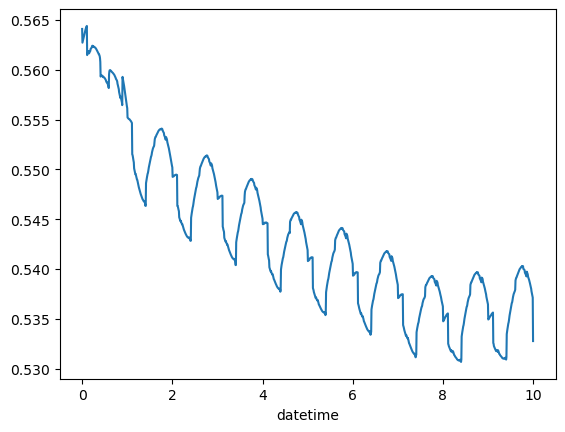

In [45]:
fig, ax = plt.subplots()
fconcat_decay.mean('tswot').mean('drifter_id').plot(ax=ax)
#decay.plot(ax=ax)

In [82]:
def low_filter(ds, T=1, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        ds[v] = xr.DataArray(
            filtfilt(taps, 1, ds[v]),
            dims=["alti_key","frequency_band", "time"],
            )
    return ds
dsd = low_filter(dssf, T=1, cutoff = 0.5, vars_ = ['B_ggd'])  

<xarray.DataArray (tswot: 40, datetime: 2880)> Size: 922kB
array([[        nan,         nan,         nan, ...,  0.62082489,
         0.64510338,  0.66874733],
       [        nan,         nan,         nan, ..., -0.88982553,
        -0.87507879, -0.8594713 ],
       [        nan,         nan,         nan, ..., -0.27431069,
        -0.30433183, -0.33405362],
       ...,
       [ 0.83965685,  0.82221231,  0.80395903, ..., -0.95605148,
        -0.96477569, -0.97255092],
       [ 0.36923377,  0.39819519,  0.42676493, ...,  0.47373923,
         0.44588951,  0.41760121],
       [-0.98344318, -0.97727674, -0.97014903, ...,  0.77156883,
         0.79113822,  0.80992943]])
Coordinates:
    drifter_type  <U7 28B 'SPOTTER'
    drifter_id    <U15 60B '147'
    time          (tswot, datetime) float64 922kB nan nan nan ... 48.99 48.99
  * datetime      (datetime) float64 23kB -10.0 -9.993 -9.986 ... 9.986 9.993
  * tswot         (tswot) int64 320B 0 1 2 3 4 5 6 7 ... 32 33 34 35 36 37 38 39